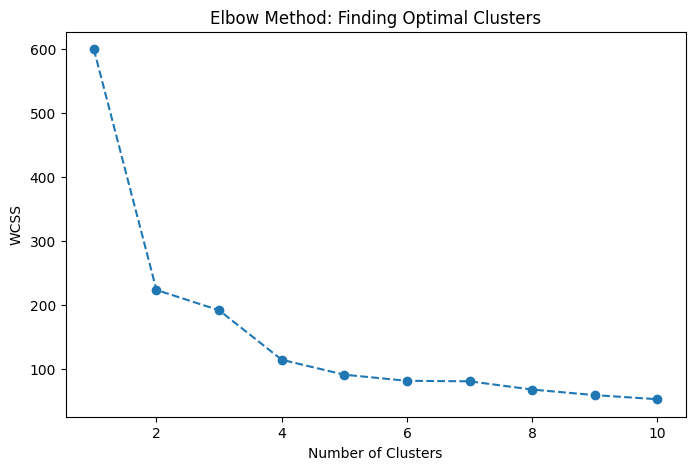

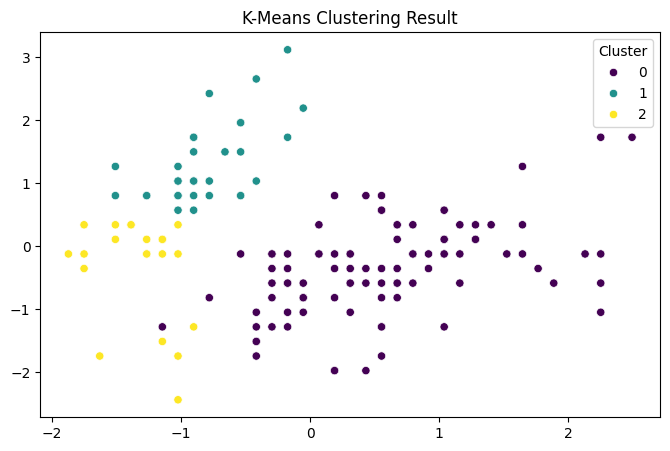

In [ ]:
#importing the python libaries for analysis and visulization
import pandas as pd #read the csv file (iris.csv)
import matplotlib.pyplot as plt #for plotting the graphs
import seaborn as sns #To make graphs more interactive 
from sklearn.cluster import KMeans #divides data into groups
from sklearn.preprocessing import StandardScaler #it normalize the data

#data preaparation - loading iris dataset and removing target variables for unsupervised learning
df = pd.read_csv('iris.csv')
X = df.drop('species', axis=1) 

# STANDARDIZATION - scaling features to ensure all dimensions contribute equally to the distance calculation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaler = StandardScaler()

#ELBOW METHOD - finding the optimal number of clusters by calculating the within-cluster WCSS
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method: Finding Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.savefig('Elbow_Method.png') #saving the image of optimization result
plt.show()

#CLUSTERING- applying k-means with the optimal number of clusters (3) based on elbow method.
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

#VISUALIZATION - plotting ther final clusters toshow how the algorithm grouped the data points.
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['Cluster'], palette='viridis')
plt.title('K-Means Clustering Result')
plt.savefig('KMeans_Clusters.png')
plt.show()